# Stock Price Prediction Using Decision Tree Model
EE 559 - Machine Learning I

Name: Sungje Park


In [1]:
import pandas as pd
import jax
import jax.numpy as jnp
import optax
import numpy as np
from tqdm import tqdm
from functools import partial
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

## Load dataset

In [2]:
train_data = pd.read_pickle('datasets/tall/train_data.pickle')
valid_data = pd.read_pickle('datasets/tall/valid_data.pickle')
test_data = pd.read_pickle('datasets/tall/test_data.pickle')

# train_mask = pd.read_pickle('datasets/tall/train_mask.pickle')
# valid_mask = pd.read_pickle('datasets/tall/valid_mask.pickle')
# test_mask = pd.read_pickle('datasets/tall/test_mask.pickle')

In [3]:
train_data.head()

,Open_ret_prev_close,High_ret_prev_close,Low_ret_prev_close,Close_ret_prev_close,rel_volume_yday,rel_adj_close,target_rel_adj_close
0,0.000000,0.009740,-0.009740,0.009740,-0.044109,0.009739,2.572377e-02
1,0.015000,0.035000,0.015000,0.020000,0.893365,0.020000,-9.803232e-03
2,0.000000,0.015328,-0.001226,0.015328,0.326862,0.015328,-6.409386e-09
3,0.000000,0.016778,0.000000,0.013423,-0.047573,0.013422,-2.778242e-07
4,-0.005017,-0.005017,-0.013378,-0.010033,-0.309835,-0.010039,-1.182966e-02


In [4]:
def seperate_x_y(df):
    x = jnp.asarray(df.drop(columns=['target_rel_adj_close']))
    y = jnp.asarray(df['target_rel_adj_close'])[...,jnp.newaxis]
    return x, y

train_data_x,train_data_y = seperate_x_y(train_data)
valid_data_x,valid_data_y = seperate_x_y(valid_data)
test_data_x,test_data_y = seperate_x_y(test_data)
print(f"Train data X shape: {train_data_x.shape}, Train data Y shape: {train_data_y.shape}")

Train data X shape: (3203872, 6), Train data Y shape: (3203872, 1)


E0504 20:01:09.986444  377047 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 104.85GiB (112582705152 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0504 20:01:09.986937  377047 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 94.37GiB (101324431360 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0504 20:01:09.987431  377047 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 84.93GiB (91191984128 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0504 20:01:09.987915  377047 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 76.44GiB (82072780800 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0504 20:01:09.988390  377047 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 68.79GiB (73865502720

## Model Training

In [5]:
max_depth = 5
min_samples_leaf = 20

In [6]:
model = DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
model.fit(train_data_x, train_data_y.flatten())

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

In [7]:
# @jax.jit
def raw_eval(x,y):
    pred = model.predict(x)[...,None]
    mse = (pred - y)**2
    sign_pred = jnp.sign(pred.flatten())
    sign_true = jnp.sign(y.flatten())
    accuracy = sign_pred == sign_true
    positive_pred = sign_pred > 0
    positive_true = sign_true > 0
    return mse, accuracy, positive_pred, positive_true

def batch_evaluate(x,y,batch_size):
    num_samples = x.shape[0]
    mse = []
    accuracy = []
    positive_pred = []
    positive_true = []
    for i in range(0, num_samples, batch_size):
        batch_x = x[i:i+batch_size]
        batch_y = y[i:i+batch_size]
        batch_mse, batch_acc, batch_pos_pred, batch_pos_true = raw_eval(batch_x, batch_y)
        mse.append(batch_mse)
        accuracy.append(batch_acc)
        positive_pred.append(batch_pos_pred)
        positive_true.append(batch_pos_true)
    mse = jnp.mean(jnp.concatenate(mse))
    accuracy = jnp.mean(jnp.concatenate(accuracy))
    pred_pos = jnp.concatenate(positive_pred)
    true_pos = jnp.concatenate(positive_true)
    tp = jnp.sum(pred_pos & true_pos)
    fp = jnp.sum(pred_pos & ~true_pos)
    fn = jnp.sum((~pred_pos) & true_pos)
    eps = 1e-12
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return mse, accuracy, precision, recall, f1
        
def print_eval_metrics(mse, acc, precision, recall, f1, dataset_name):
    print(f"{dataset_name} MSE: {mse:.6f}, Sign Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

In [8]:
eval_batch = 1024

train_mse, train_acc, train_precision, train_recall, train_f1 = batch_evaluate(train_data_x, train_data_y,eval_batch)
print_eval_metrics(train_mse, train_acc, train_precision, train_recall, train_f1, "Train")
valid_mse, valid_acc, valid_precision, valid_recall, valid_f1 = batch_evaluate(valid_data_x, valid_data_y,eval_batch)
print_eval_metrics(valid_mse, valid_acc, valid_precision, valid_recall, valid_f1, "Validation")
test_mse, test_acc, test_precision, test_recall, test_f1 = batch_evaluate(test_data_x, test_data_y,eval_batch)
print_eval_metrics(test_mse, test_acc, test_precision, test_recall, test_f1, "Test")

Train MSE: 0.000750, Sign Accuracy: 0.4325, Precision: 0.4277, Recall: 0.9826, F1: 0.5960
Validation MSE: 0.000542, Sign Accuracy: 0.5059, Precision: 0.5043, Recall: 0.9871, F1: 0.6676
Test MSE: 0.000877, Sign Accuracy: 0.5051, Precision: 0.5038, Recall: 0.9862, F1: 0.6669


## Ablations

In [9]:
max_depths = [2,3,5,8,10,15,20]
min_leafs = [1,5,10,20,30]

In [10]:
min_samples_leaf = 10

train_stats_depth = []
valid_stats_depth = []
for max_depth in max_depths:
    model = DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
    model.fit(train_data_x, train_data_y.flatten())
    train_stat = batch_evaluate(train_data_x, train_data_y,eval_batch)
    valid_stat = batch_evaluate(valid_data_x, valid_data_y,eval_batch)
    train_stats_depth.append(train_stat)
    valid_stats_depth.append(valid_stat)

In [11]:
max_depth = 5

train_stats_leaf = []
valid_stats_leaf = []
for min_samples_leaf in min_leafs:
    model = DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
    model.fit(train_data_x, train_data_y.flatten())
    train_stat = batch_evaluate(train_data_x, train_data_y,eval_batch)
    valid_stat = batch_evaluate(valid_data_x, valid_data_y,eval_batch)
    train_stats_leaf.append(train_stat)
    valid_stats_leaf.append(valid_stat)

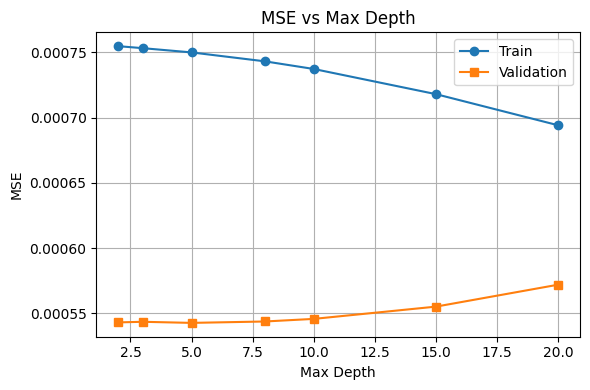

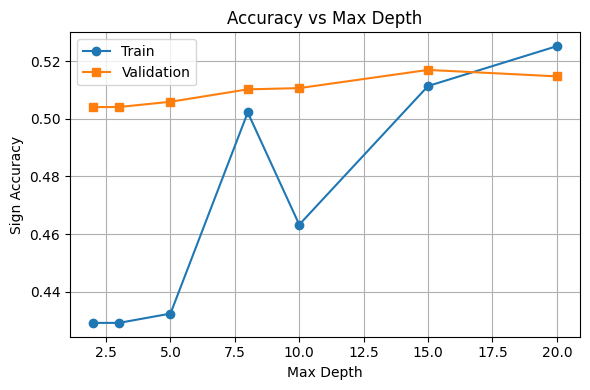

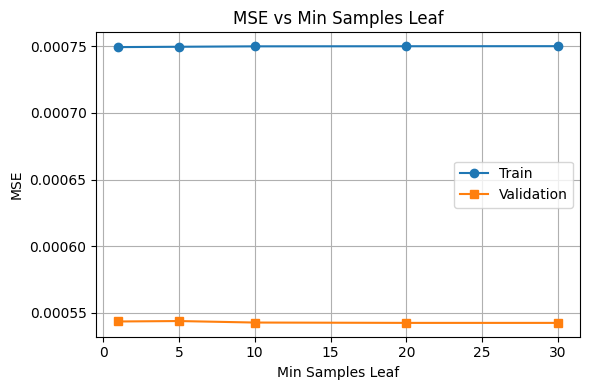

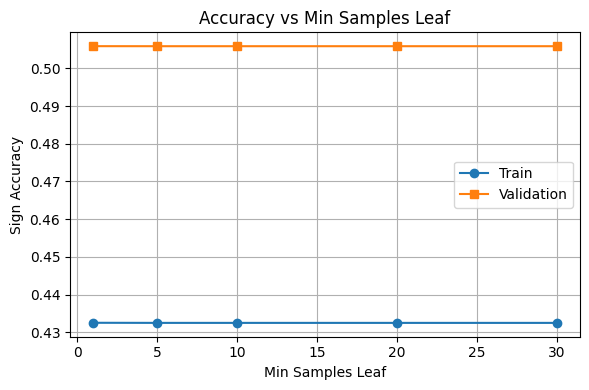

In [12]:

# Extract metrics for max_depth ablation
train_mse_depth = [stat[0] for stat in train_stats_depth]
valid_mse_depth = [stat[0] for stat in valid_stats_depth]
train_acc_depth = [stat[1] for stat in train_stats_depth]
valid_acc_depth = [stat[1] for stat in valid_stats_depth]

# Extract metrics for min_samples_leaf ablation
train_mse_leaf = [stat[0] for stat in train_stats_leaf]
valid_mse_leaf = [stat[0] for stat in valid_stats_leaf]
train_acc_leaf = [stat[1] for stat in train_stats_leaf]
valid_acc_leaf = [stat[1] for stat in valid_stats_leaf]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(max_depths, train_mse_depth, marker='o', label='Train')
ax.plot(max_depths, valid_mse_depth, marker='s', label='Validation')
ax.set_xlabel('Max Depth')
ax.set_ylabel('MSE')
ax.set_title('MSE vs Max Depth')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('figures/mse_vs_max_depth.png')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(max_depths, train_acc_depth, marker='o', label='Train')
ax.plot(max_depths, valid_acc_depth, marker='s', label='Validation')
ax.set_xlabel('Max Depth')
ax.set_ylabel('Sign Accuracy')
ax.set_title('Accuracy vs Max Depth')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('figures/accuracy_vs_max_depth.png')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(min_leafs, train_mse_leaf, marker='o', label='Train')
ax.plot(min_leafs, valid_mse_leaf, marker='s', label='Validation')
ax.set_xlabel('Min Samples Leaf')
ax.set_ylabel('MSE')
ax.set_title('MSE vs Min Samples Leaf')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('figures/mse_vs_min_samples_leaf.png')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(min_leafs, train_acc_leaf, marker='o', label='Train')
ax.plot(min_leafs, valid_acc_leaf, marker='s', label='Validation')
ax.set_xlabel('Min Samples Leaf')
ax.set_ylabel('Sign Accuracy')
ax.set_title('Accuracy vs Min Samples Leaf')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('figures/accuracy_vs_min_samples_leaf.png')
plt.show()